- Nate Diaz-Santana
- Applied Data Science

In [2]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Predicting Obesity Levels in Latin American Cities

## Data Import & Preparation

In [5]:
data = pd.read_csv("ObesityDataSet.csv")

In [6]:
data.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [7]:
data = data.rename(columns={'family_history_with_overweight':'FamilyHistory', 'FAVC':'HighCalories', 'FCVC':'Vegetables', 'NCP':'DailyMeals', 'CAEC':'Snacks', 'SMOKE':'Smoke', 'CH2O':'WaterIntake', 'SCC':'CalorieMonitoring', 'FAF':'PhysicalActivity', 'TUE':'TechnologyUse', 'CALC':'AlcoholIntake', 'MTRANS':'Transportation', 'NObeyesdad':'ObesityLevel'})

In [8]:
data.tail()

,Gender,Age,Height,Weight,FamilyHistory,HighCalories,Vegetables,DailyMeals,Snacks,Smoke,WaterIntake,CalorieMonitoring,PhysicalActivity,TechnologyUse,AlcoholIntake,Transportation,ObesityLevel
2106,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,Sometimes,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III
2107,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,Sometimes,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III
2108,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,Sometimes,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III
2109,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,Sometimes,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III
2110,Female,23.664709,1.738836,133.472641,yes,yes,3.0,3.0,Sometimes,no,2.863513,no,1.026452,0.714137,Sometimes,Public_Transportation,Obesity_Type_III


In [9]:
data['ObesityLevel'].value_counts()

ObesityLevel
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64

In [10]:
numeric_cols = ["Age", "Vegetables", "DailyMeals", "WaterIntake", "PhysicalActivity", "TechnologyUse"]
rdata = data.copy(deep=True)
rdata[numeric_cols] = rdata[numeric_cols].round(0)

In [11]:
rdata['Transportation'].value_counts()

Transportation
Public_Transportation    1580
Automobile                457
Walking                    56
Motorbike                  11
Bike                        7
Name: count, dtype: int64

In [12]:
rdata['Vegetables'] = rdata['Vegetables'].replace({
    1.0: 'Never',
    2.0: 'Sometimes',
    3.0: 'Always'
})

In [13]:
rdata['DailyMeals'] = rdata['DailyMeals'].replace({
    1.0: 'Between 1 and 2',
    2.0: 'Between 1 and 2',
    3.0: 'Three',
    4.0: 'More than 3'
})

In [14]:
rdata['WaterIntake'] = rdata['WaterIntake'].replace({
    1.0: 'Less than a liter',
    2.0: 'Between 1 and 2 liters',
    3.0: 'More than 2 liters'
})

In [15]:
rdata['Snacks'] = rdata['Snacks'].replace({
    'no': 'No'
})

In [16]:
rdata['PhysicalActivity'] = rdata['PhysicalActivity'].replace({
    0.0: 'Never',
    1.0: '1 or 2 days',
    2.0: '2 or 4 days',
    3.0: '4 or 5 days'
})

In [17]:
rdata['TechnologyUse'] = rdata['TechnologyUse'].replace({
    0.0: '0-2 Hours',
    1.0: '3-5 Hours',
    2.0: 'More than 5 hours'
})

In [18]:
rdata['ObesityLevel'] = rdata['ObesityLevel'].replace({
    'Insufficient_Weight': 'Underweight',
    'Normal_Weight': 'NormalWeight',
    'Overweight_Level_I': 'OverweightLevel1',
    'Overweight_Level_II': 'OverweightLevel2',
    'Obesity_Type_I': 'ObesityType1',
    'Obesity_Type_II': 'ObesityType2',
    'Obesity_Type_III': 'ObesityType3'
})

In [19]:
rdata.tail()

,Gender,Age,Height,Weight,FamilyHistory,HighCalories,Vegetables,DailyMeals,Snacks,Smoke,WaterIntake,CalorieMonitoring,PhysicalActivity,TechnologyUse,AlcoholIntake,Transportation,ObesityLevel
2106,Female,21.0,1.710730,131.408528,yes,yes,Always,Three,Sometimes,no,Between 1 and 2 liters,no,2 or 4 days,3-5 Hours,Sometimes,Public_Transportation,ObesityType3
2107,Female,22.0,1.748584,133.742943,yes,yes,Always,Three,Sometimes,no,Between 1 and 2 liters,no,1 or 2 days,3-5 Hours,Sometimes,Public_Transportation,ObesityType3
2108,Female,23.0,1.752206,133.689352,yes,yes,Always,Three,Sometimes,no,Between 1 and 2 liters,no,1 or 2 days,3-5 Hours,Sometimes,Public_Transportation,ObesityType3
2109,Female,24.0,1.739450,133.346641,yes,yes,Always,Three,Sometimes,no,More than 2 liters,no,1 or 2 days,3-5 Hours,Sometimes,Public_Transportation,ObesityType3
2110,Female,24.0,1.738836,133.472641,yes,yes,Always,Three,Sometimes,no,More than 2 liters,no,1 or 2 days,3-5 Hours,Sometimes,Public_Transportation,ObesityType3


In [20]:
rdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             2111 non-null   object 
 1   Age                2111 non-null   float64
 2   Height             2111 non-null   float64
 3   Weight             2111 non-null   float64
 4   FamilyHistory      2111 non-null   object 
 5   HighCalories       2111 non-null   object 
 6   Vegetables         2111 non-null   object 
 7   DailyMeals         2111 non-null   object 
 8   Snacks             2111 non-null   object 
 9   Smoke              2111 non-null   object 
 10  WaterIntake        2111 non-null   object 
 11  CalorieMonitoring  2111 non-null   object 
 12  PhysicalActivity   2111 non-null   object 
 13  TechnologyUse      2111 non-null   object 
 14  AlcoholIntake      2111 non-null   object 
 15  Transportation     2111 non-null   object 
 16  ObesityLevel       2111 

## EDA

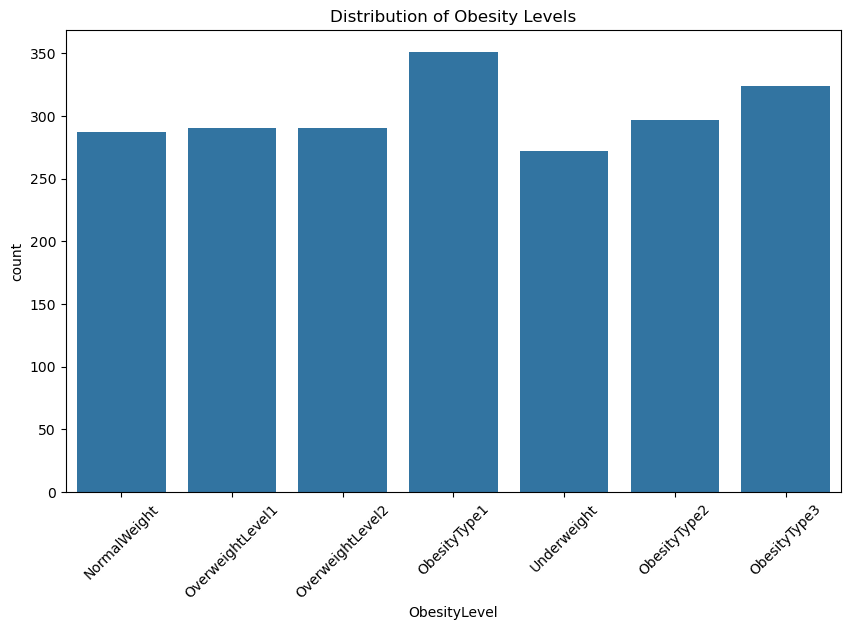

In [22]:
plt.figure(figsize=(10,6))
sb.countplot(data=rdata, x='ObesityLevel')
plt.xticks(rotation=45)
plt.title("Distribution of Obesity Levels")
plt.show()

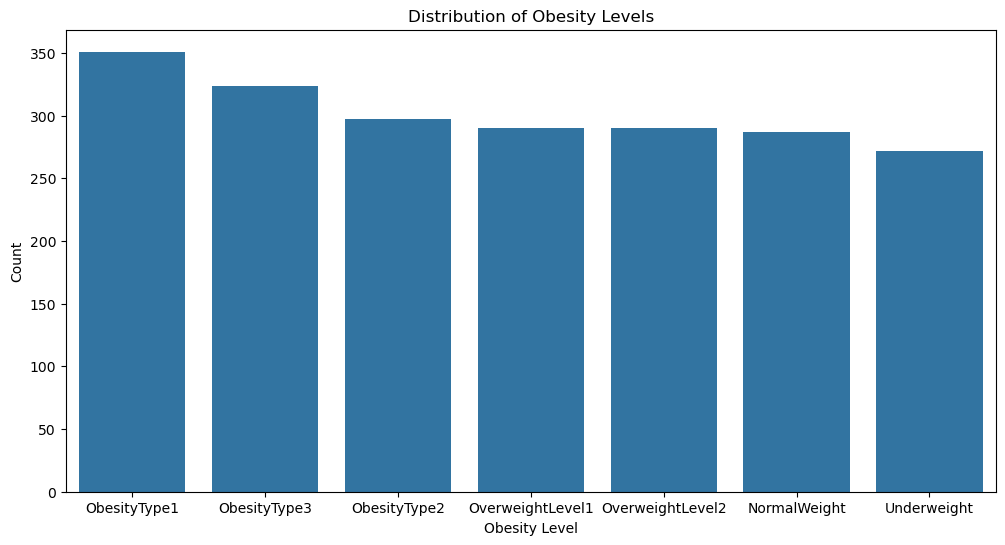

In [23]:
plt.figure(figsize=(12,6))
sb.countplot(data=rdata, x='ObesityLevel', order=rdata['ObesityLevel'].value_counts().index)
plt.title("Distribution of Obesity Levels")
plt.xlabel("Obesity Level")
plt.ylabel("Count")
plt.show()

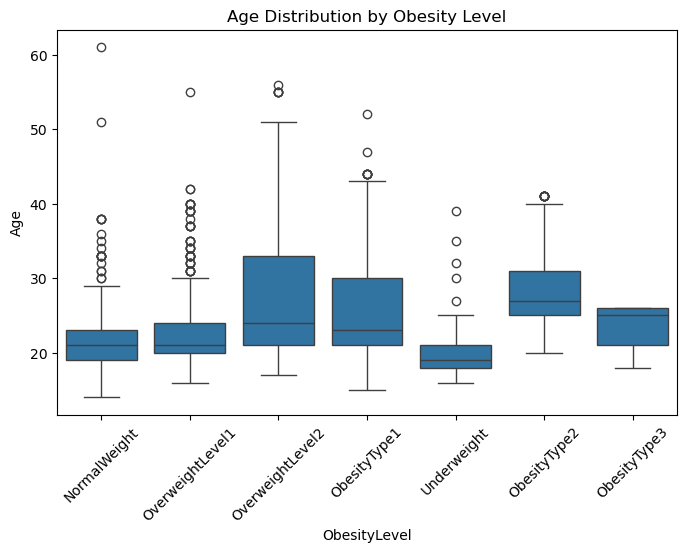

In [24]:
plt.figure(figsize=(8,5))
sb.boxplot(data=rdata, x='ObesityLevel', y='Age')
plt.title("Age Distribution by Obesity Level")
plt.xticks(rotation=45)
plt.show()

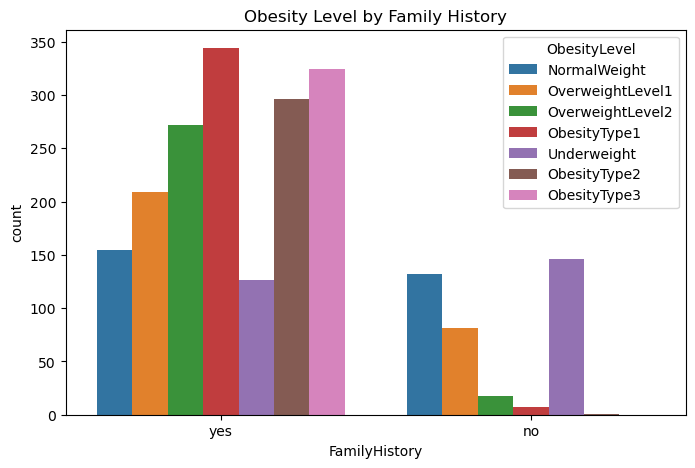

In [25]:
plt.figure(figsize=(8,5))
sb.countplot(data=rdata, x='FamilyHistory', hue='ObesityLevel')
plt.title("Obesity Level by Family History")
plt.show()

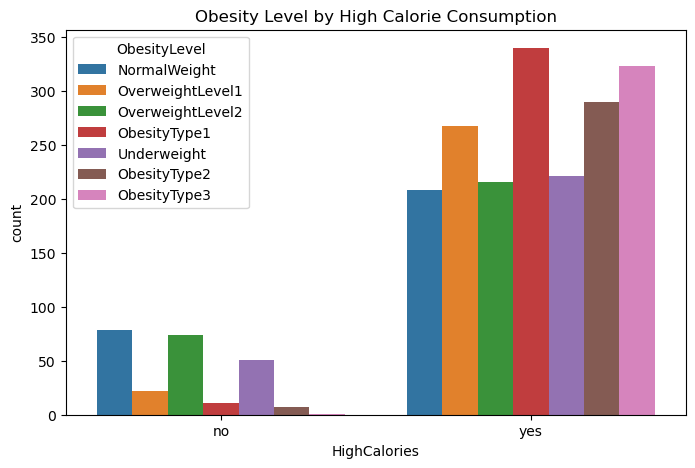

In [26]:
plt.figure(figsize=(8,5))
sb.countplot(data=rdata, x='HighCalories', hue='ObesityLevel')
plt.title("Obesity Level by High Calorie Consumption")
plt.show()

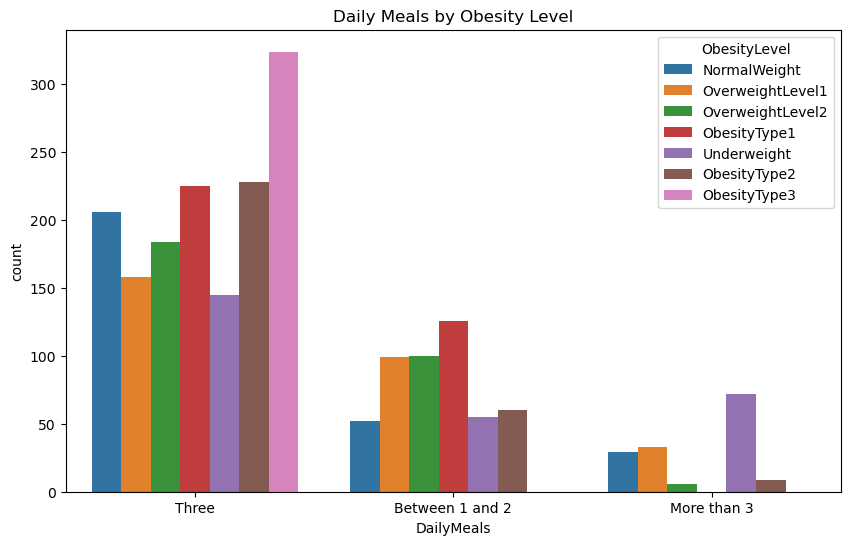

In [27]:
plt.figure(figsize=(10,6))
sb.countplot(data=rdata, x='DailyMeals', hue='ObesityLevel')
plt.title("Daily Meals by Obesity Level")
plt.show()

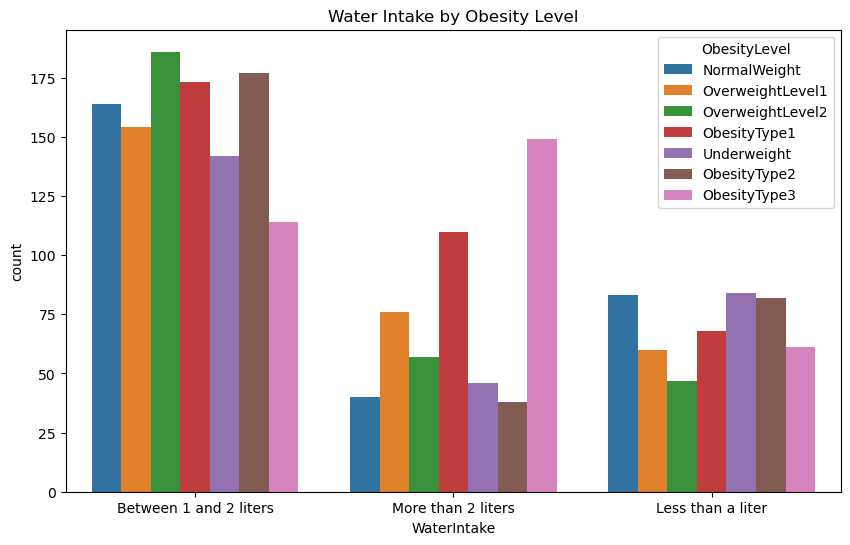

In [28]:
plt.figure(figsize=(10,6))
sb.countplot(data=rdata, x='WaterIntake', hue='ObesityLevel')
plt.title("Water Intake by Obesity Level")
plt.show()

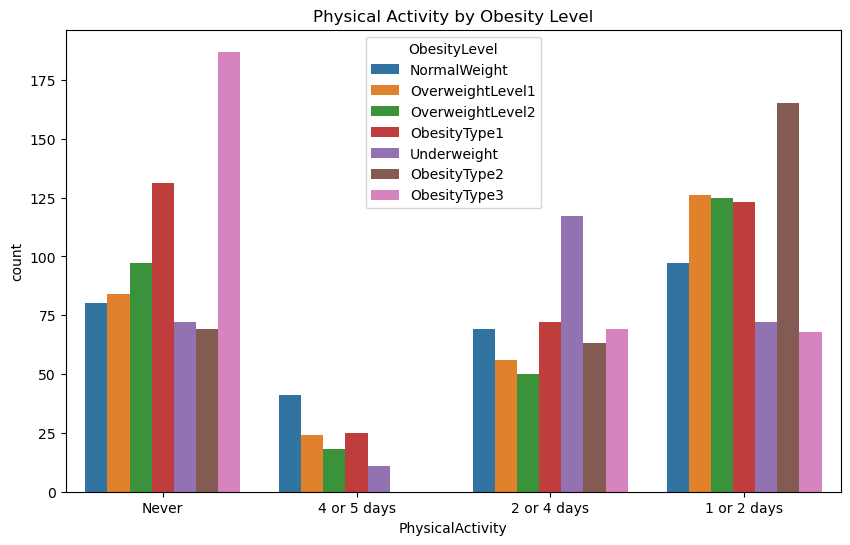

In [29]:
plt.figure(figsize=(10,6))
sb.countplot(data=rdata, x='PhysicalActivity', hue='ObesityLevel')
plt.title("Physical Activity by Obesity Level")
plt.show()

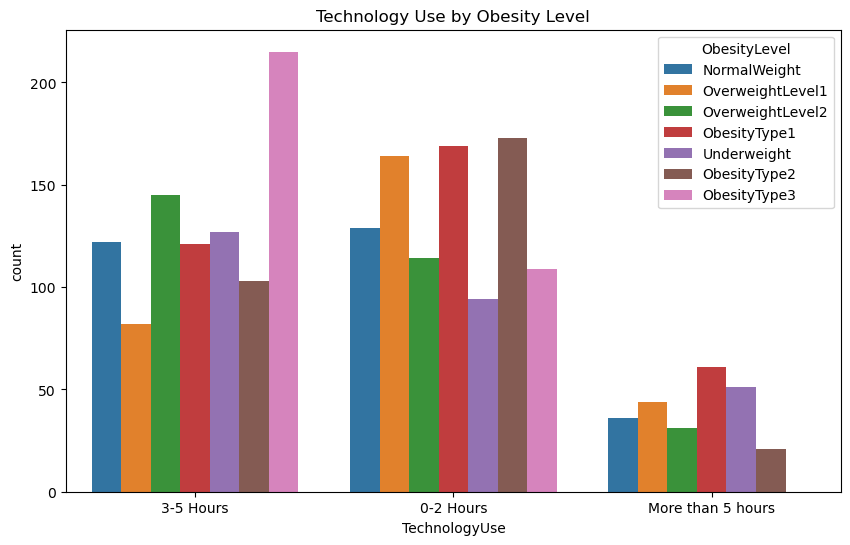

In [30]:
plt.figure(figsize=(10,6))
sb.countplot(data=rdata, x='TechnologyUse', hue='ObesityLevel')
plt.title("Technology Use by Obesity Level")
plt.show()

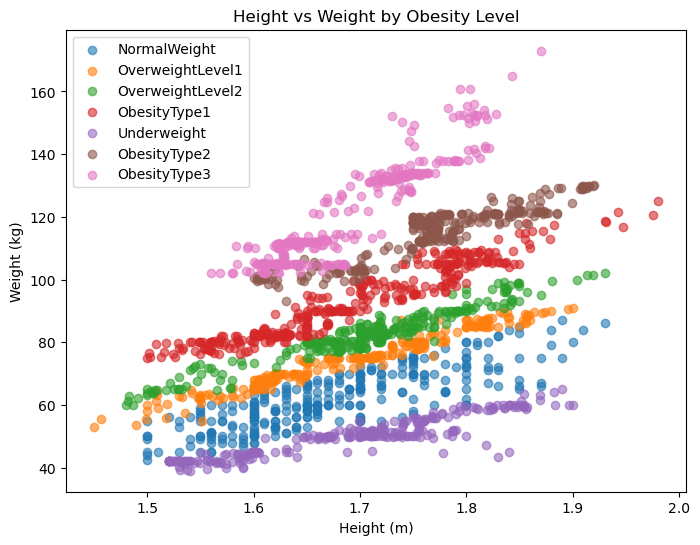

In [31]:
plt.figure(figsize=(8,6))
levels = rdata['ObesityLevel'].unique()
cmap = plt.get_cmap('tab10')
colors = {level: cmap(i) for i, level in enumerate(levels)}

for level in levels:
    subset = rdata[rdata['ObesityLevel'] == level]
    plt.scatter(subset['Height'], subset['Weight'], c=[colors[level]], label=level, alpha=0.6)

plt.xlabel("Height (m)")
plt.ylabel("Weight (kg)")
plt.title("Height vs Weight by Obesity Level")
plt.legend()
plt.show()

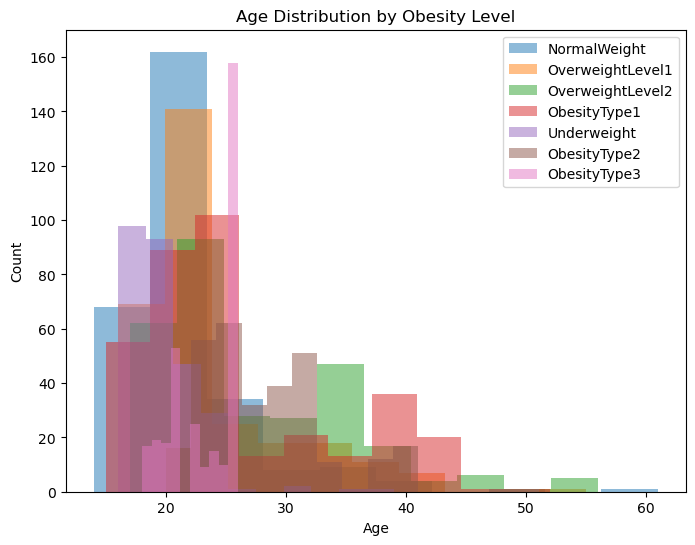

In [32]:
plt.figure(figsize=(8,6))
for level in levels:
    subset = rdata[rdata['ObesityLevel'] == level]
    plt.hist(subset['Age'], bins=10, alpha=0.5, label=level)

plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age Distribution by Obesity Level")
plt.legend()
plt.show()

## Modeling

In [34]:
y = rdata['ObesityLevel']

Xbd = rdata.drop(columns=[
    'ObesityLevel',
    'Weight',
    'Height'
])

Xb = Xbd.drop(columns=[
    'Age',
    'Gender',
])

In [35]:
Xbd_train, Xbd_test, ybd_train, ybd_test = train_test_split(
    Xbd, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    Xb, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [36]:
def build_pipeline(X, classifier):

    categorical_cols = X.select_dtypes(include='object').columns
    numerical_cols = X.select_dtypes(include=['float64']).columns

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numerical_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
        ]
    )

    model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', classifier)
    ])

    return model

In [37]:
log_clf = LogisticRegression(max_iter=3000, multi_class='multinomial')

rf_clf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

gb_clf = GradientBoostingClassifier()

In [38]:
models_bd = {
    "Logistic Regression": build_pipeline(Xbd, LogisticRegression(max_iter=3000)),
    "Random Forest": build_pipeline(Xbd, RandomForestClassifier(n_estimators=300, random_state=42)),
    "Gradient Boosting": build_pipeline(Xbd, GradientBoostingClassifier())
}

for name, model in models_bd.items():
    model.fit(Xbd_train, ybd_train)

In [39]:
models_b = {
    "Logistic Regression": build_pipeline(Xb, LogisticRegression(max_iter=3000)),
    "Random Forest": build_pipeline(Xb, RandomForestClassifier(n_estimators=300, random_state=42)),
    "Gradient Boosting": build_pipeline(Xb, GradientBoostingClassifier())
}

for name, model in models_b.items():
    model.fit(Xb_train, yb_train)

In [40]:
results = []

print("=== Behavioral + Demographics ===")
for name, model in models_bd.items():
    y_pred = model.predict(Xbd_test)
    acc = accuracy_score(ybd_test, y_pred)
    results.append(("Behavioral + Demographics", name, acc))
    print(f"{name}: {acc:.4f}")

print("\n=== Behavioral-Only ===")
for name, model in models_b.items():
    y_pred = model.predict(Xb_test)
    acc = accuracy_score(yb_test, y_pred)
    results.append(("Pure Behavioral", name, acc))
    print(f"{name}: {acc:.4f}")

=== Behavioral + Demographics ===
Logistic Regression: 0.6170
Random Forest: 0.8274
Gradient Boosting: 0.7612

=== Behavioral-Only ===
Logistic Regression: 0.5650
Random Forest: 0.7139
Gradient Boosting: 0.6643


In [41]:
datasets = {
    "Behavioral + Demographics": (Xbd_test, ybd_test, models_bd),
    "Behavioral-Only": (Xb_test, yb_test, models_b)
}

for feature_set, (X_test, y_test, models) in datasets.items():
    print(f"\n=== {feature_set} ===\n")
    for name, model in models.items():
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        print(f"--- {name} ---")
        print(f"Accuracy: {acc:.4f}\n")
        print("Classification Report:")
        print(classification_report(y_test, y_pred, digits=4))
        print("Confusion Matrix:")
        cm = confusion_matrix(y_test, y_pred)
        cm_df = pd.DataFrame(cm, index=y_test.unique(), columns=y_test.unique())
        display(cm_df)
        print("\n" + "-"*60 + "\n")


=== Behavioral + Demographics ===

--- Logistic Regression ---
Accuracy: 0.6170

Classification Report:
                  precision    recall  f1-score   support

    NormalWeight     0.5098    0.4483    0.4771        58
    ObesityType1     0.5641    0.6286    0.5946        70
    ObesityType2     0.5802    0.7833    0.6667        60
    ObesityType3     0.9155    1.0000    0.9559        65
OverweightLevel1     0.5714    0.4138    0.4800        58
OverweightLevel2     0.4255    0.3448    0.3810        58
     Underweight     0.6604    0.6481    0.6542        54

        accuracy                         0.6170       423
       macro avg     0.6039    0.6096    0.6013       423
    weighted avg     0.6072    0.6170    0.6068       423

Confusion Matrix:


,ObesityType2,ObesityType1,OverweightLevel2,ObesityType3,NormalWeight,OverweightLevel1,Underweight
ObesityType2,26,0,4,1,8,7,12
ObesityType1,3,44,6,2,4,10,1
OverweightLevel2,2,3,47,0,2,6,0
ObesityType3,0,0,0,65,0,0,0
NormalWeight,8,11,8,0,24,3,4
OverweightLevel1,2,16,15,3,1,20,1
Underweight,10,4,1,0,3,1,35



------------------------------------------------------------

--- Random Forest ---
Accuracy: 0.8274

Classification Report:
                  precision    recall  f1-score   support

    NormalWeight     0.6207    0.6207    0.6207        58
    ObesityType1     0.8571    0.8571    0.8571        70
    ObesityType2     0.8615    0.9333    0.8960        60
    ObesityType3     0.9848    1.0000    0.9924        65
OverweightLevel1     0.7857    0.7586    0.7719        58
OverweightLevel2     0.8148    0.7586    0.7857        58
     Underweight     0.8333    0.8333    0.8333        54

        accuracy                         0.8274       423
       macro avg     0.8226    0.8231    0.8225       423
    weighted avg     0.8263    0.8274    0.8265       423

Confusion Matrix:


,ObesityType2,ObesityType1,OverweightLevel2,ObesityType3,NormalWeight,OverweightLevel1,Underweight
ObesityType2,36,3,2,0,6,4,7
ObesityType1,2,60,1,0,5,1,1
OverweightLevel2,1,1,56,0,0,2,0
ObesityType3,0,0,0,65,0,0,0
NormalWeight,8,1,2,0,44,3,0
OverweightLevel1,3,5,4,1,0,44,1
Underweight,8,0,0,0,1,0,45



------------------------------------------------------------

--- Gradient Boosting ---
Accuracy: 0.7612

Classification Report:
                  precision    recall  f1-score   support

    NormalWeight     0.6415    0.5862    0.6126        58
    ObesityType1     0.7027    0.7429    0.7222        70
    ObesityType2     0.8182    0.9000    0.8571        60
    ObesityType3     0.9559    1.0000    0.9774        65
OverweightLevel1     0.7255    0.6379    0.6789        58
OverweightLevel2     0.7115    0.6379    0.6727        58
     Underweight     0.7288    0.7963    0.7611        54

        accuracy                         0.7612       423
       macro avg     0.7549    0.7573    0.7546       423
    weighted avg     0.7573    0.7612    0.7578       423

Confusion Matrix:


...


------------------------------------------------------------

--- Random Forest ---
Accuracy: 0.7139

Classification Report:
                  precision    recall  f1-score   support

    NormalWeight     0.6078    0.5345    0.5688        58
    ObesityType1     0.7123    0.7429    0.7273        70
    ObesityType2     0.6623    0.8500    0.7445        60
    ObesityType3     0.9275    0.9846    0.9552        65
OverweightLevel1     0.6122    0.5172    0.5607        58
OverweightLevel2     0.7000    0.6034    0.6481        58
     Underweight     0.7222    0.7222    0.7222        54

        accuracy                         0.7139       423
       macro avg     0.7064    0.7078    0.7038       423
    weighted avg     0.7098    0.7139    0.7087       423

Confusion Matrix:


,ObesityType2,ObesityType1,OverweightLevel2,ObesityType3,NormalWeight,OverweightLevel1,Underweight
ObesityType2,31,4,3,0,7,5,8
ObesityType1,1,52,4,1,5,4,3
OverweightLevel2,1,2,51,2,2,1,1
ObesityType3,0,0,1,64,0,0,0
NormalWeight,6,5,11,0,30,5,1
OverweightLevel1,3,8,6,2,2,35,2
Underweight,9,2,1,0,3,0,39



------------------------------------------------------------

--- Gradient Boosting ---
Accuracy: 0.6643

Classification Report:
                  precision    recall  f1-score   support

    NormalWeight     0.5741    0.5345    0.5536        58
    ObesityType1     0.5543    0.7286    0.6296        70
    ObesityType2     0.6620    0.7833    0.7176        60
    ObesityType3     0.9275    0.9846    0.9552        65
OverweightLevel1     0.6875    0.3793    0.4889        58
OverweightLevel2     0.5577    0.5000    0.5273        58
     Underweight     0.6981    0.6852    0.6916        54

        accuracy                         0.6643       423
       macro avg     0.6659    0.6565    0.6520       423
    weighted avg     0.6667    0.6643    0.6563       423

Confusion Matrix:


,ObesityType2,ObesityType1,OverweightLevel2,ObesityType3,NormalWeight,OverweightLevel1,Underweight
ObesityType2,31,6,3,0,5,4,9
ObesityType1,3,51,3,1,0,11,1
OverweightLevel2,1,6,47,2,0,3,1
ObesityType3,0,0,1,64,0,0,0
NormalWeight,6,11,12,0,22,4,3
OverweightLevel1,2,16,5,2,2,29,2
Underweight,11,2,0,0,3,1,37



------------------------------------------------------------



### Results Visualizations

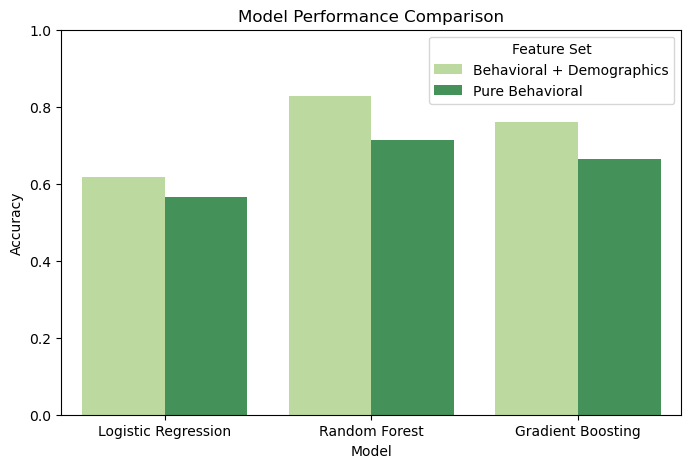

In [43]:
results = pd.DataFrame(results, columns=["Feature Set", "Model", "Accuracy"])

plt.figure(figsize=(8,5))
sb.barplot(data=results, x="Model", y="Accuracy", hue="Feature Set", palette="YlGn")
plt.ylim(0,1)
plt.title("Model Performance Comparison")
plt.show()

In [44]:
rf_bd = models_bd["Random Forest"].named_steps['classifier']
rf_b = models_b["Random Forest"].named_steps['classifier']

feature_names_bd = models_bd["Random Forest"].named_steps['preprocessor'].get_feature_names_out()
feature_names_b = models_b["Random Forest"].named_steps['preprocessor'].get_feature_names_out()

importances_bd = rf_bd.feature_importances_
importances_b = rf_b.feature_importances_

feat_bd = pd.DataFrame({
    'Feature': feature_names_bd,
    'Importance': importances_bd
}).sort_values(by='Importance', ascending=False)

feat_b = pd.DataFrame({
    'Feature': feature_names_b,
    'Importance': importances_b
}).sort_values(by='Importance', ascending=False)

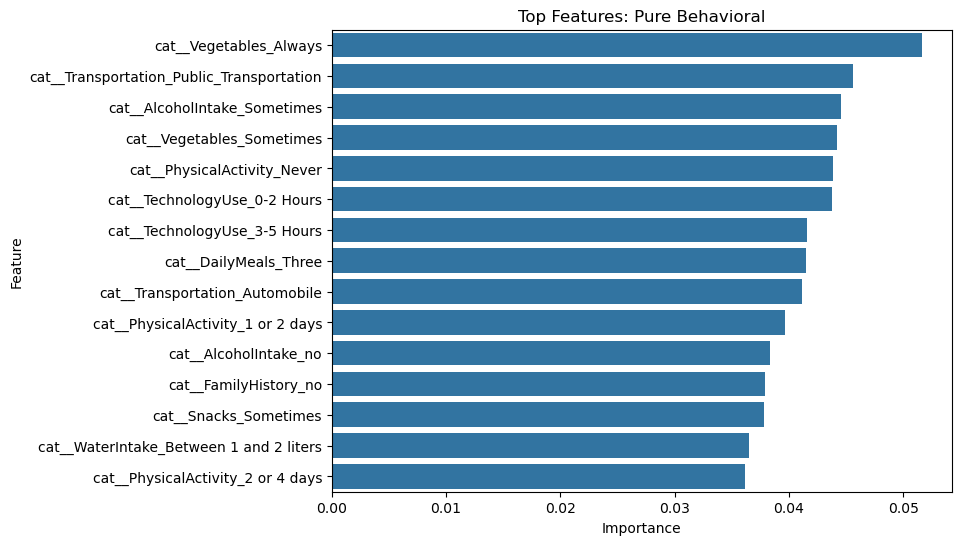

In [45]:
plt.figure(figsize=(8,6))
sb.barplot(data=feat_b.head(15), x='Importance', y='Feature')
plt.title("Top Features: Pure Behavioral")
plt.show()

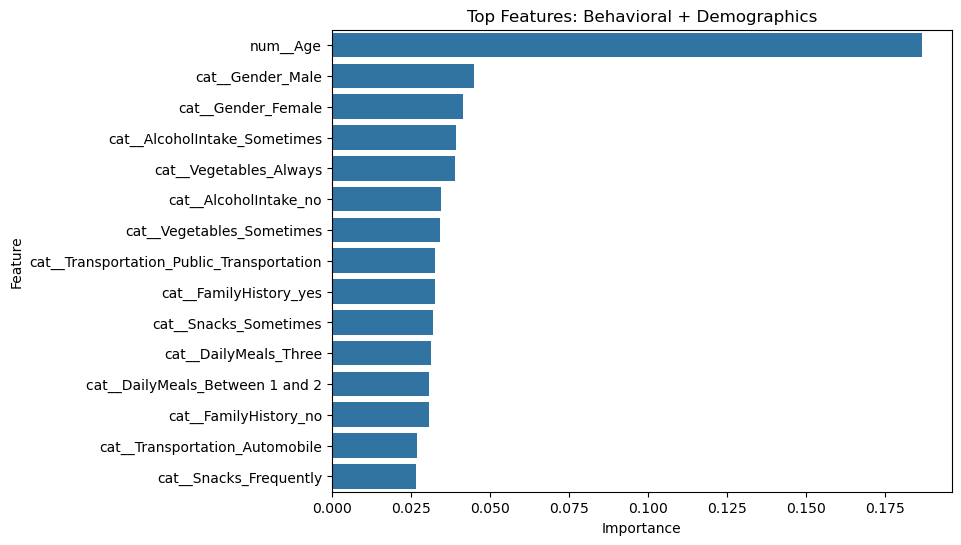

In [46]:
plt.figure(figsize=(8,6))
sb.barplot(data=feat_bd.head(15), x='Importance', y='Feature')
plt.title("Top Features: Behavioral + Demographics")
plt.show()

In [47]:
feat_b.head(15)

,Feature,Importance
4,cat__Vegetables_Always,0.051644
35,cat__Transportation_Public_Transportation,0.045593
30,cat__AlcoholIntake_Sometimes,0.044508
6,cat__Vegetables_Sometimes,0.044219
24,cat__PhysicalActivity_Never,0.043796
25,cat__TechnologyUse_0-2 Hours,0.043715
26,cat__TechnologyUse_3-5 Hours,0.041555
9,cat__DailyMeals_Three,0.041514
32,cat__Transportation_Automobile,0.041125
21,cat__PhysicalActivity_1 or 2 days,0.039674


In [48]:
feat_bd.head(15)

,Feature,Importance
0,num__Age,0.186664
2,cat__Gender_Male,0.045034
1,cat__Gender_Female,0.041495
33,cat__AlcoholIntake_Sometimes,0.039321
7,cat__Vegetables_Always,0.039043
34,cat__AlcoholIntake_no,0.034532
9,cat__Vegetables_Sometimes,0.034235
38,cat__Transportation_Public_Transportation,0.032757
4,cat__FamilyHistory_yes,0.032528
16,cat__Snacks_Sometimes,0.032119


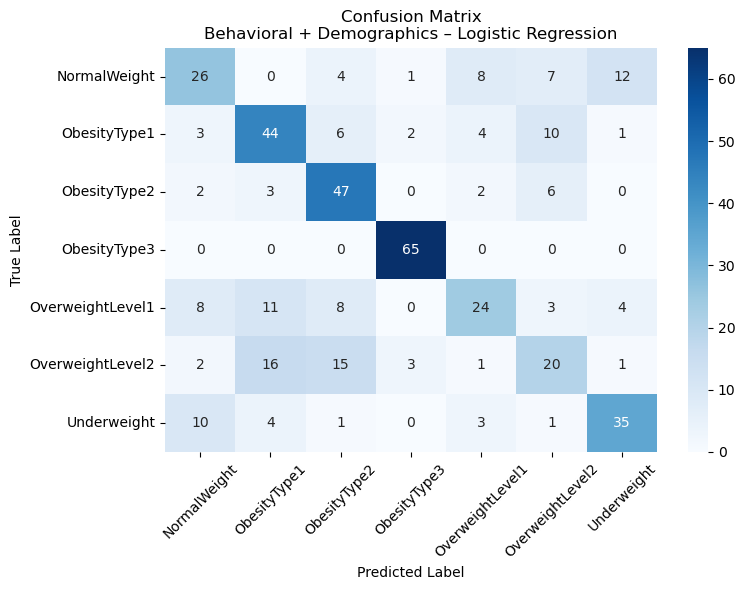

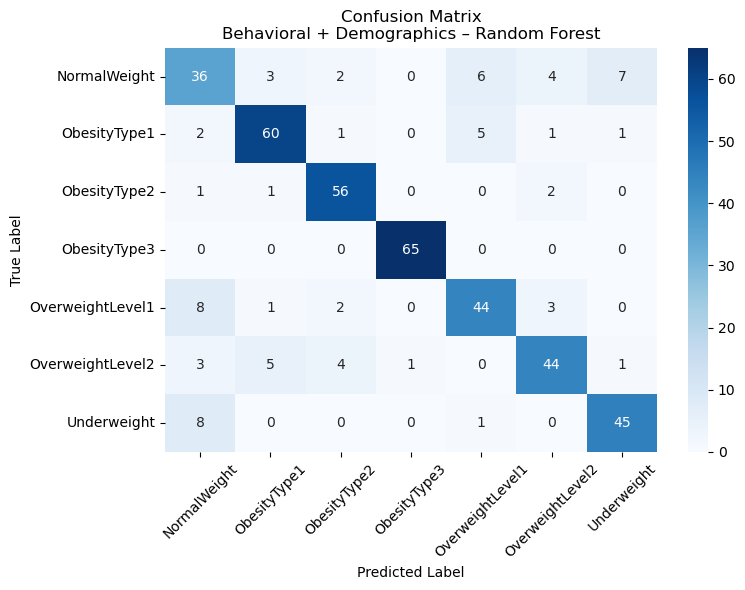

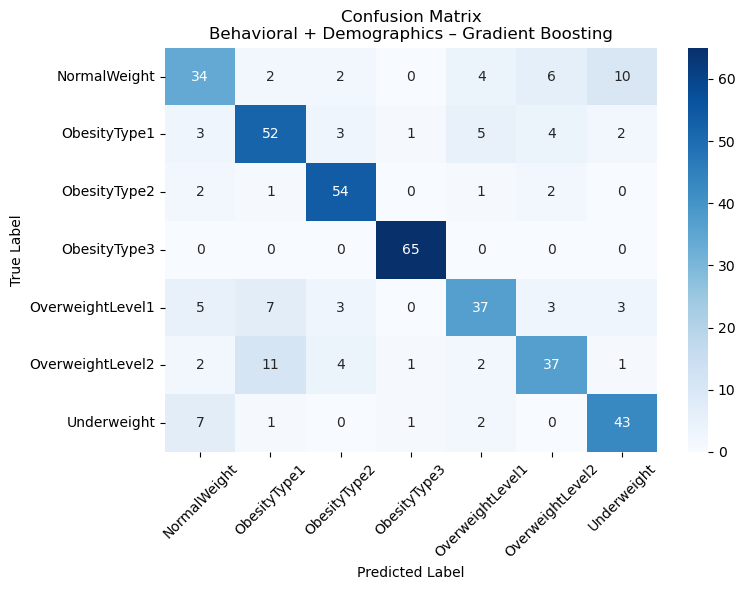

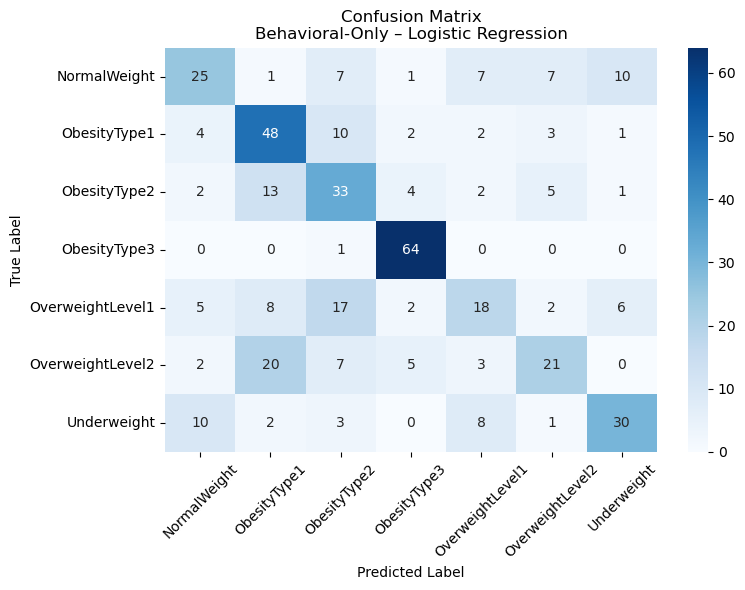

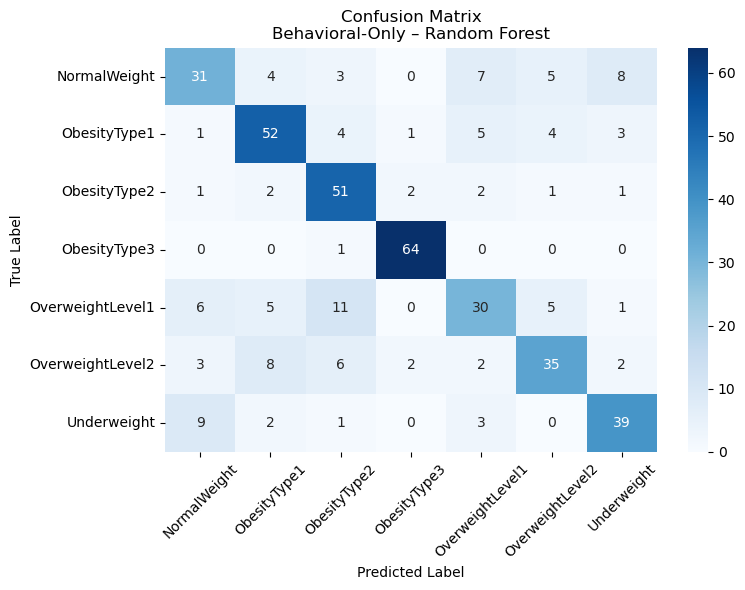

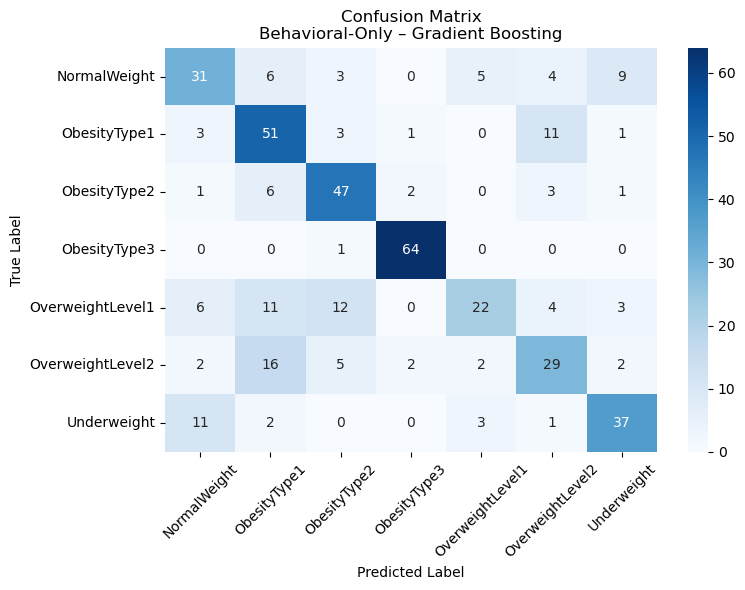

In [49]:
class_labels = sorted(y.unique())

for feature_set, (X_test, y_test, models) in datasets.items():
    
    for model_name, model in models.items():
        
        y_pred = model.predict(X_test)
        cm = confusion_matrix(y_test, y_pred, labels=class_labels)
        
        plt.figure(figsize=(8,6))
        sb.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=class_labels,
            yticklabels=class_labels
        )
        
        plt.xlabel("Predicted Label")
        plt.ylabel("True Label")
        plt.title(f"Confusion Matrix\n{feature_set} – {model_name}")
        plt.xticks(rotation=45)
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()

In [50]:
rf_preds_b = models_b["Random Forest"].predict(Xb_test)
cm_b = confusion_matrix(yb_test, rf_preds_b, labels=class_labels)
acc_b = cm_b.diagonal() / cm_b.sum(axis=1)

rf_preds_bd = models_bd["Random Forest"].predict(Xbd_test)
cm_bd = confusion_matrix(ybd_test, rf_preds_bd, labels=class_labels)
acc_bd = cm_bd.diagonal() / cm_bd.sum(axis=1)

improvement = acc_bd - acc_b
improvement_series = pd.Series(improvement, index=class_labels).sort_values(ascending=False)

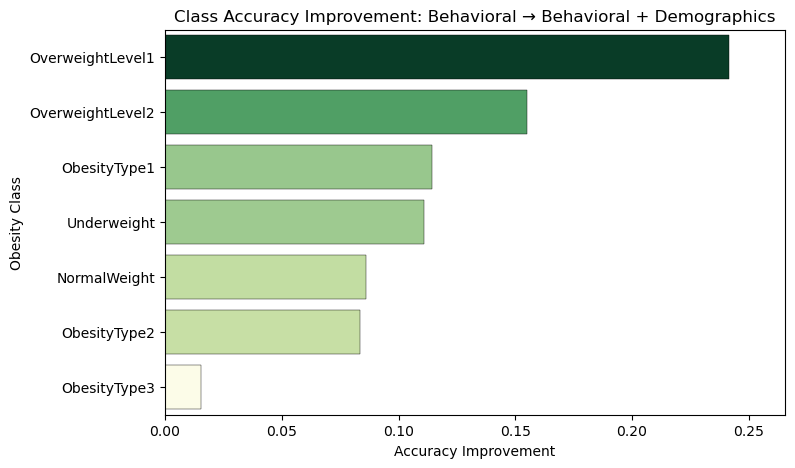

In [51]:
plt.figure(figsize=(8,5))
sb.barplot(x=improvement_series.values, y=improvement_series.index, hue=improvement_series.values, edgecolor="black", linewidth=0.3, palette="YlGn", legend=False)
plt.xlabel("Accuracy Improvement")
plt.ylabel("Obesity Class")
plt.title("Class Accuracy Improvement: Behavioral → Behavioral + Demographics")
plt.xlim(0, max(improvement_series.values)*1.1)
plt.show()